In [2]:
import database
import pandas as pd

In [3]:
conn = database.connect_to_database()
df = database.fetch_data(conn)

In [4]:
# Thu thập và hiểu dữ liệu

# Mục tiêu: Tính delay time = currenttraveltime - freeflowtraveltime (thời gian chờ do tắc nghẽn).
# Tập trung vào 3 tuyến đường và 3 khung giờ (lọc từ time: giờ từ 6-8, 11-12, 16-17).
# Đặt câu hỏi ban đầu:
# - Delay time có cao hơn ở khung giờ cao điểm (6-8h)?
# - Thời tiết (như "Light rain") có kết hợp với tuyến đường nào để gây delay lớn?
# - Distance có ảnh hưởng (ví dụ: delay cao hơn gần đích do ùn tắc cuối đường)?

df['time'] = pd.to_datetime(df['time'])  # Chuyển time thành datetime
df['delay_time'] = df['currenttraveltime'] - df['freeflowtraveltime']  # Tính delay
df['hour'] = df['time'].dt.hour  # Trích giờ để lọc khung
# Lọc dữ liệu cho 3 khung giờ
df_filtered = df[df['hour'].isin([6, 7, 11, 12, 16])]
print(df_filtered.describe())  # Thống kê mô tả ban đầu
print(df_filtered['description'].unique())  # Kiểm tra 3 tuyến đường

                id                           time         hour
count  4525.000000                           4525  4525.000000
mean   4128.016575  2025-07-27 09:54:03.977900544    10.348066
min     704.000000            2025-07-19 11:15:00     6.000000
25%    2435.000000            2025-07-23 11:18:00     7.000000
50%    4091.000000            2025-07-27 07:50:00    11.000000
75%    5872.000000            2025-07-31 11:17:00    12.000000
max    7578.000000            2025-08-04 12:44:00    16.000000
std    1994.113174                            NaN     3.630441
['Từ Ngã Sáu Cộng Hòa đến An Dương Vương'
 'Từ Cầu Nguyễn Văn Cừ đến An Dương Vương'
 'Từ Vòng Xoay Trần Phú đến ĐHSP']


In [5]:
# Làm sạch dữ liệu

# Xử lý missing: Kiểm tra null (ví dụ: nếu precip_mm hoặc vis_km thiếu, thay bằng 0 hoặc trung bình).
#                Dữ liệu dường như đầy đủ, nhưng kiểm tra confidence <1 có thể loại nếu thấp quá (ví dụ: giữ >0.9).
# Xử lý ngoại lai: Phát hiện outlier ở delay_time (ví dụ: delay âm hoặc quá lớn), currentspeed (nếu <0).
#                  Sử dụng boxplot để xem.
# Chuẩn hóa: Chuyển condition_text thành category (ví dụ: mã hóa "Light rain" thành nhóm).
#            Lọc chỉ 3 tuyến đường từ description. Xử lý roadclosure nếu có True (có thể loại vì gây delay vô hạn).
#            Nhóm distance thành bins (ví dụ: gần đích <200m, xa >500m) để dễ áp dụng association rules.

df_filtered = df_filtered.dropna()  # Loại null nếu có
df_filtered = df_filtered[df_filtered['delay_time'] >= 0]  # Loại delay âm
df_filtered = df_filtered[df_filtered['roadclosure'] == False]  # Loại đường đóng
# Nhóm distance thành categorical cho association rules
df_filtered['distance_bin'] = pd.cut(df_filtered['distance'], bins=[0, 200, 500, float('inf')], labels=['Near', 'Medium', 'Far'])
# Mã hóa thời tiết và khung giờ
df_filtered['time_slot'] = pd.cut(df_filtered['hour'],
                                 bins=[6, 8, 12, 17],
                                 labels=['6-8', '11-12', '16-17'],
                                 right=False)
df_filtered['condition_text'] = df_filtered['condition_text'].astype('category')
df_filtered.head(3)

,id,description,time,distance,frc,currentspeed,freeflowspeed,currenttraveltime,freeflowtraveltime,confidence,...,latitude,longitude,precip_mm,vis_km,wind_kph,condition_text,delay_time,hour,distance_bin,time_slot
0,1854,Từ Ngã Sáu Cộng Hòa đến An Dương Vương,2025-07-22 06:54:00,500,FRC3,21,32,1195,784,1,...,10.765163027177051,106.68176325830919,0.0,10.0,29.2,Light rain,411,6,Medium,6-8
1,1855,Từ Ngã Sáu Cộng Hòa đến An Dương Vương,2025-07-22 06:54:00,400,FRC3,21,32,1195,784,1,...,10.764283334954333,106.68210132878986,0.0,10.0,29.2,Light rain,411,6,Medium,6-8
2,1856,Từ Ngã Sáu Cộng Hòa đến An Dương Vương,2025-07-22 06:54:00,300,FRC3,21,32,1195,784,1,...,10.763480856227291,106.68240386571111,0.0,10.0,29.2,Light rain,411,6,Medium,6-8


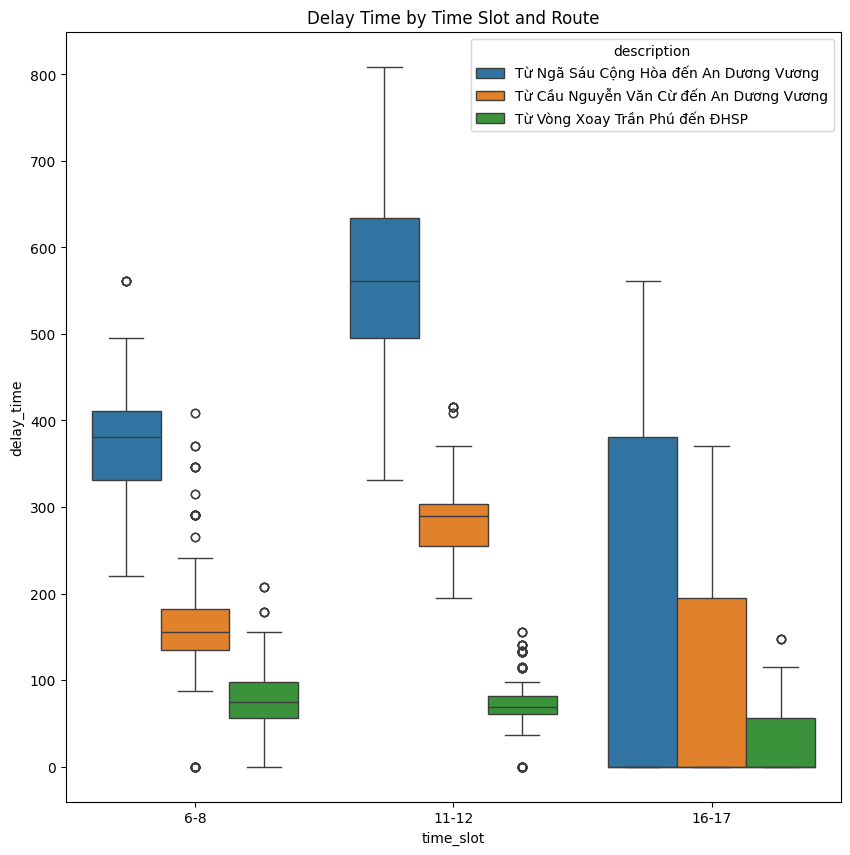

In [6]:
# Khám phá dữ liệu (EDA)

# Thống kê mô tả: Tính trung bình/độ lệch delay_time theo tuyến đường, khung giờ, thời tiết.
# Ví dụ: Delay trung bình ở tuyến "Từ Ngã Sáu Cộng Hòa đến An Dương Vương" trong 6-8h.

import matplotlib.pyplot as plt
import seaborn as sns

# Visualize:

# Biểu đồ histogram/boxplot cho delay_time theo khung giờ.
plt.figure(figsize=(10, 10))
sns.boxplot(x='time_slot', y='delay_time', hue='description', data=df_filtered)
plt.title('Delay Time by Time Slot and Route')
plt.show()

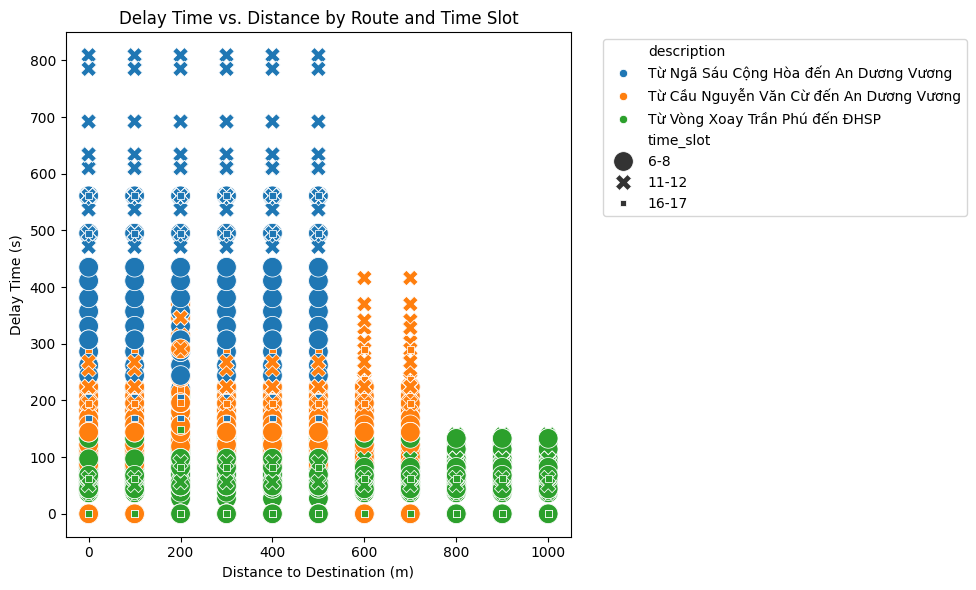

In [7]:
# Scatter plot: delay_time vs. distance (xem delay cao hơn gần đích?).
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_filtered, x='distance', y='delay_time', hue='description', style='time_slot', size='time_slot', sizes=(50, 200))
plt.title('Delay Time vs. Distance by Route and Time Slot')
plt.xlabel('Distance to Destination (m)')
plt.ylabel('Delay Time (s)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

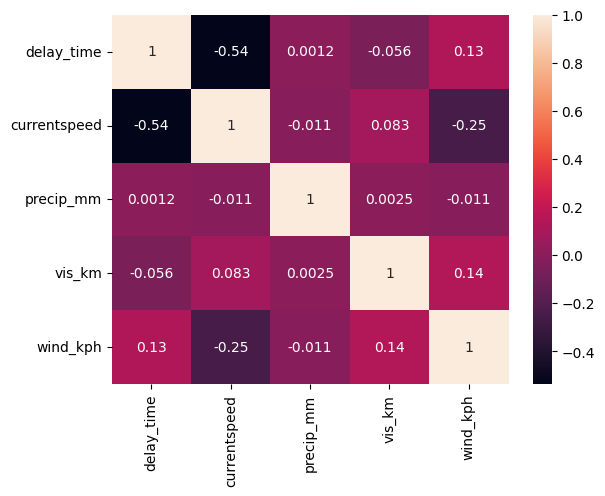

In [8]:
# Heatmap tương quan giữa currentspeed, precip_mm, wind_kph, delay_time.
corr = df_filtered[['delay_time', 'currentspeed', 'precip_mm', 'vis_km', 'wind_kph']].corr()
sns.heatmap(corr, annot=True)
plt.show()

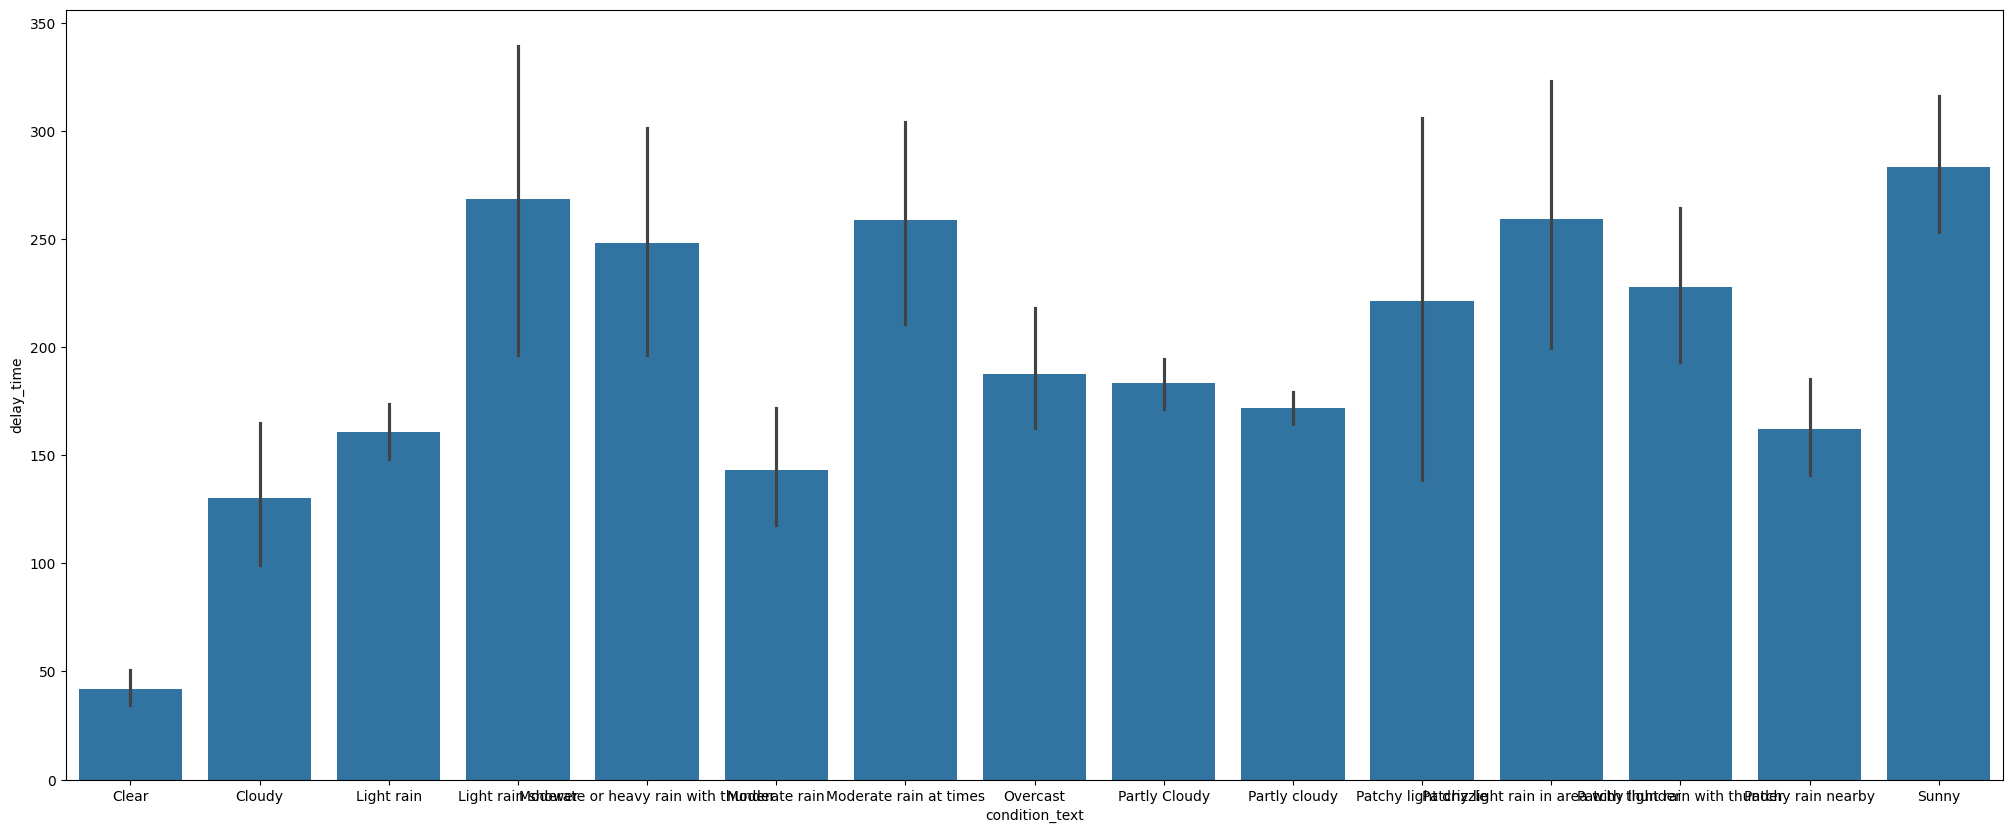

In [9]:
# Bar chart: Delay trung bình theo condition_text và tuyến đường.
plt.figure(figsize=(25, 10))
sns.barplot(x='condition_text', y='delay_time', data=df_filtered)
plt.show()

In [11]:
# Map plot (sử dụng latitude/longitude) để visualize vị trí tắc nghẽn (nếu dùng folium).
import folium
from folium.plugins import HeatMap
from IPython.display import display

# Làm sạch dữ liệu
df_filtered = df_filtered.dropna(subset=['latitude', 'longitude', 'delay_time'])
df_filtered = df_filtered[df_filtered['delay_time'] >= 0]
df_filtered = df_filtered[df_filtered['roadclosure'] == False]
df_filtered['latitude'] = df_filtered['latitude'].astype(float)
df_filtered['longitude'] = df_filtered['longitude'].astype(float)
df_filtered['delay_time'] = df_filtered['delay_time'].astype(float)

# Chuẩn hóa delay_time cho HeatMap
df_filtered['delay_time_normalized'] = df_filtered['delay_time'].clip(lower=0)
df_filtered['delay_time_normalized'] = df_filtered['delay_time_normalized'] / df_filtered['delay_time_normalized'].max()

# Tạo heat_data
heat_data = [[row['latitude'], row['longitude'], row['delay_time_normalized']] for idx, row in df_filtered.iterrows()]

# Khởi tạo bản đồ
map_center = [df_filtered['latitude'].mean(), df_filtered['longitude'].mean()]
m = folium.Map(location=map_center, zoom_start=14)

# Thêm HeatMap
HeatMap(heat_data, radius=15).add_to(m)

# Thêm CircleMarker với popup
# i = 0
# for idx, row in df_filtered.iterrows():
#     color = 'red' if row['delay_time'] > 200 else 'orange' if row['delay_time'] > 100 else 'green'
#     if i in range(, 25):
#         print(row['latitude'], row['longitude'])
#         folium.CircleMarker(
#             location=[row['latitude'], row['longitude']],
#             radius=5,
#             color=color,
#             fill=True,
#             fill_color=color,
#             fill_opacity=0.6,
#             popup=f"Route: {row['description']}<br>Time Slot: {row['time_slot']}<br>Delay: {row['delay_time']}s<br>Distance: {row['distance']}m<br>Weather: {row['condition_text']}"
#         ).add_to(m)
#     i += 1

display(m)

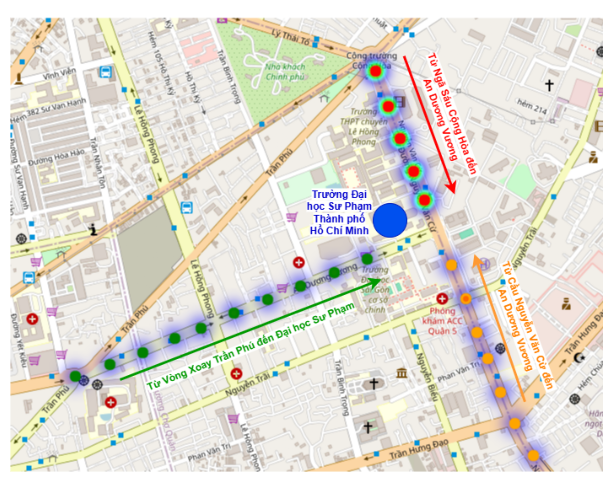

In [ ]:

import matplotlib.image as mpimg

img = mpimg.imread('show_traffic.png')  # thay bằng đường dẫn thực tế
plt.figure(figsize=(10, 6))
plt.imshow(img)
plt.axis('off')  # tắt trục nếu không cần
plt.show()

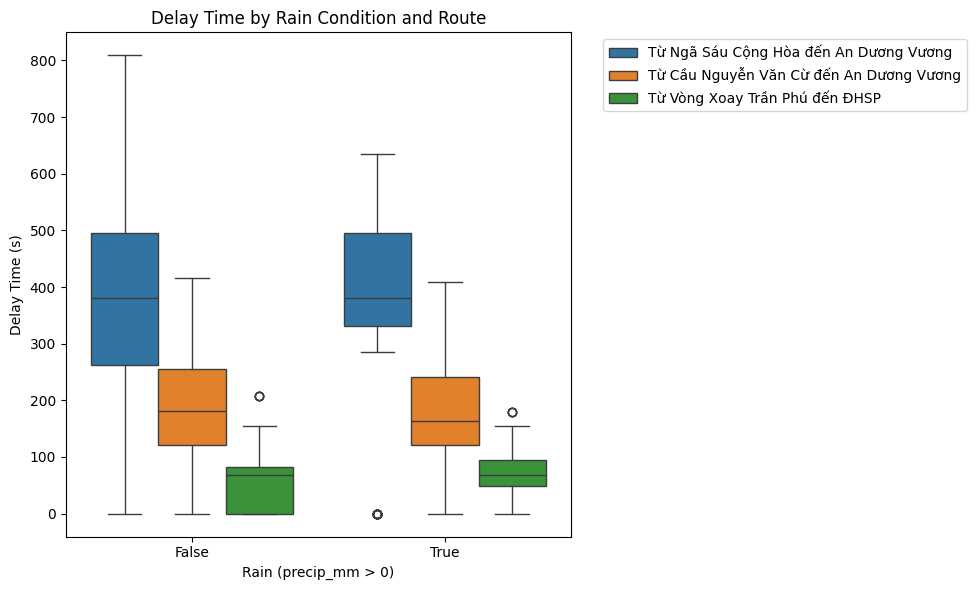

In [ ]:
# Tìm mẫu ban đầu: Xem có xu hướng như delay cao ở mưa (precip_mm >0),
#                  gió mạnh (wind_kph >20), hoặc gần đích (distance <100m).

# Thêm cột chỉ báo cho các điều kiện
df_filtered['rain'] = df_filtered['precip_mm'] > 0
df_filtered['windy'] = df_filtered['wind_kph'] > 20
df_filtered['near_destination'] = df_filtered['distance'] < 100

# Boxplot cho mưa
plt.figure(figsize=(10, 6))
sns.boxplot(x='rain', y='delay_time', hue='description', data=df_filtered)
plt.title('Delay Time by Rain Condition and Route')
plt.xlabel('Rain (precip_mm > 0)')
plt.ylabel('Delay Time (s)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

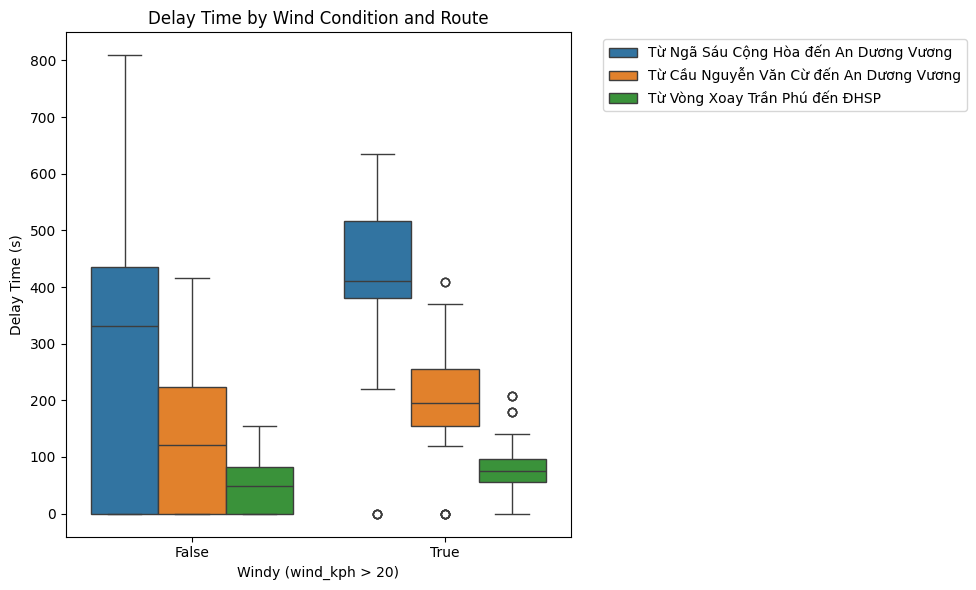

In [ ]:
# Boxplot cho gió mạnh
plt.figure(figsize=(10, 6))
sns.boxplot(x='windy', y='delay_time', hue='description', data=df_filtered)
plt.title('Delay Time by Wind Condition and Route')
plt.xlabel('Windy (wind_kph > 20)')
plt.ylabel('Delay Time (s)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

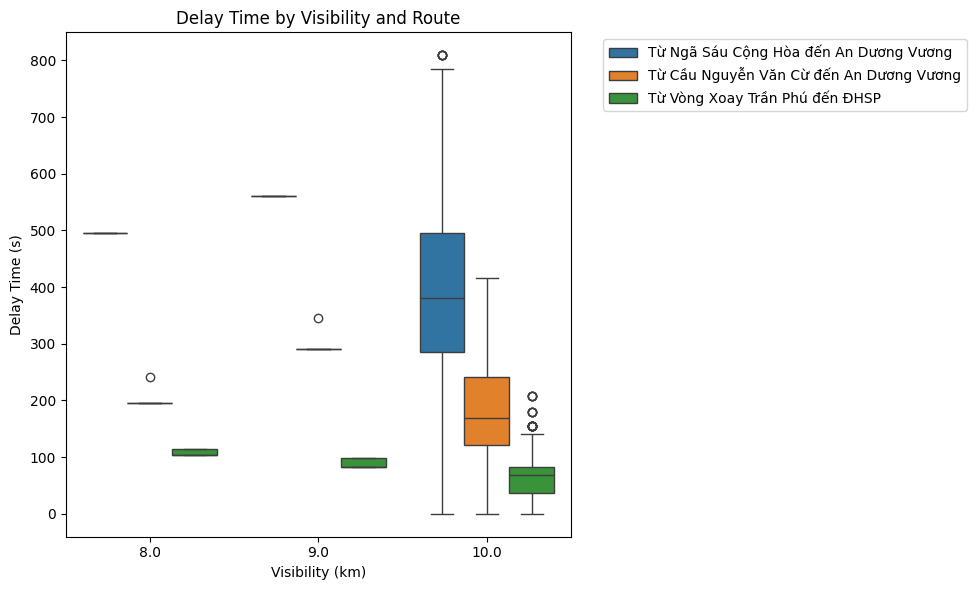

In [ ]:
# Boxplot cho vis_km theo tuyến đường
plt.figure(figsize=(10, 6))
sns.boxplot(x='vis_km', y='delay_time', hue='description', data=df_filtered)
plt.title('Delay Time by Visibility and Route')
plt.xlabel('Visibility (km)')
plt.ylabel('Delay Time (s)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

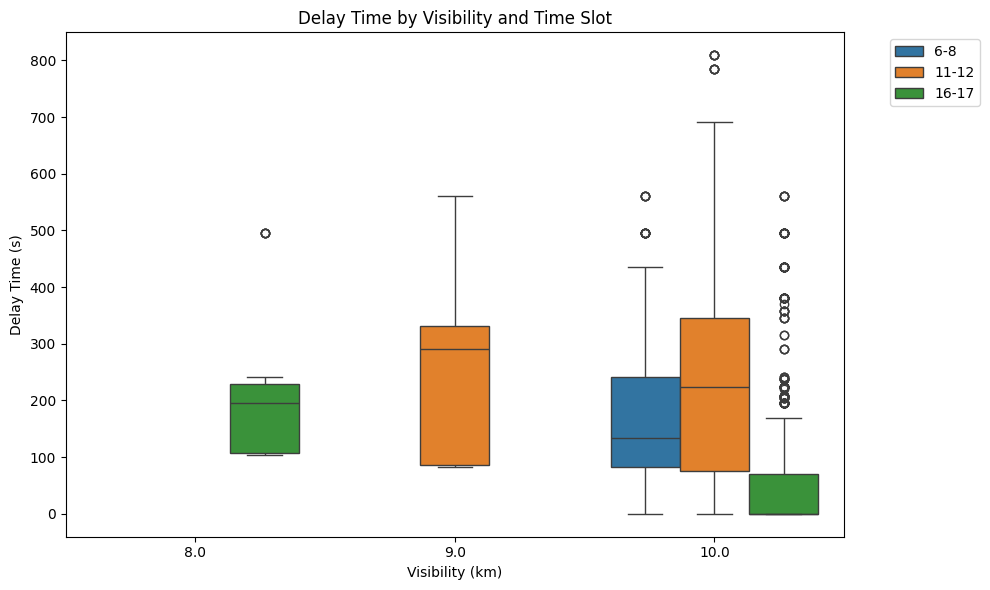

In [ ]:
# Boxplot cho vis_km theo khung giờ
plt.figure(figsize=(10, 6))
sns.boxplot(x='vis_km', y='delay_time', hue='time_slot', data=df_filtered)
plt.title('Delay Time by Visibility and Time Slot')
plt.xlabel('Visibility (km)')
plt.ylabel('Delay Time (s)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

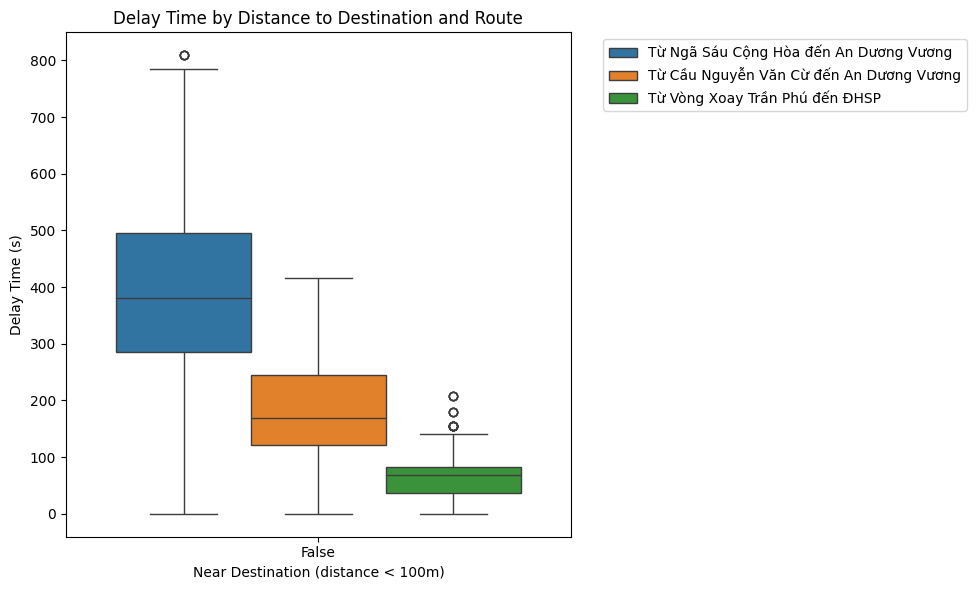

In [ ]:
# Boxplot cho gần đích
plt.figure(figsize=(10, 6))
sns.boxplot(x='near_destination', y='delay_time', hue='description', data=df_filtered)
plt.title('Delay Time by Distance to Destination and Route')
plt.xlabel('Near Destination (distance < 100m)')
plt.ylabel('Delay Time (s)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()